- Momentum: Momentum (21d), Momentum (252-21d)
- Volatility: Volatility Ratio, Historical Volatility
- Microstrcuture: Amihud Illiquidity
- Autocorrelation: Return Autocorrelation (20d)

In [45]:
import yfinance as yf
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, "/Users/giovanafalcao/Desktop/Projects/trading-analytics")
from utils import yfinance_fix
import matplotlib.pyplot as plt


TICKER = "AAPL"
INTERVAL = "1d"
PERIOD = "730d" if INTERVAL == "1h" else "max"
SHIFT = 1
LOOKBACK = 10000

def fetch_price_data(ticker = TICKER, interval = INTERVAL, period = PERIOD, shift = SHIFT, lookback = LOOKBACK):
    df = yf.download(ticker, session=yfinance_fix.chrome_session, interval = interval, period = period)
    df.columns = df.columns.get_level_values(0)

    return df.iloc[-lookback:, :]

df = fetch_price_data()
df 

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
1986-08-08,0.108127,0.110692,0.108127,0.108982,110140800
1986-08-11,0.114538,0.114538,0.108555,0.108982,183433600
1986-08-12,0.117103,0.117530,0.114111,0.114111,244160000
1986-08-13,0.123086,0.123940,0.117103,0.117103,454720000
1986-08-14,0.123086,0.126505,0.123086,0.123086,230720000
...,...,...,...,...,...
2026-04-14,258.829987,261.929993,257.190002,259.250000,48370700
2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500
2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100


Measuring Momentum:
1. Close Price Short-Term Trend - Momentum (21d): How much did the price change in the last 21 days (app. 1m)? If momentum +10%, stocks that went up recently, tend to keep going up in the short term. 
2. Close Price Long-Term Trend - Momentum (252-21d): Long-term trend (1y) minus the recent move (1m). By removing teh last 21 days, you isolate the "true" trend from recent noise. That is classic Jegadeedh and Titman Momentum factor

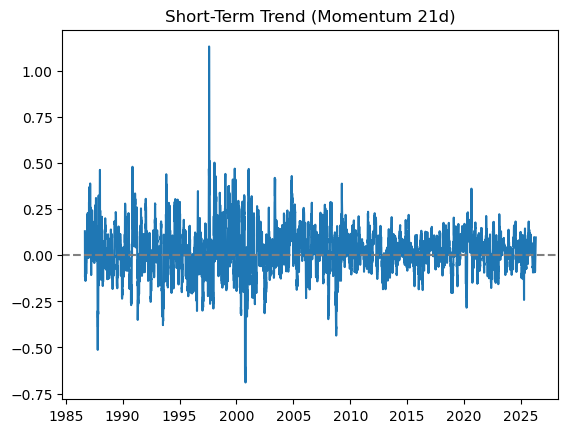

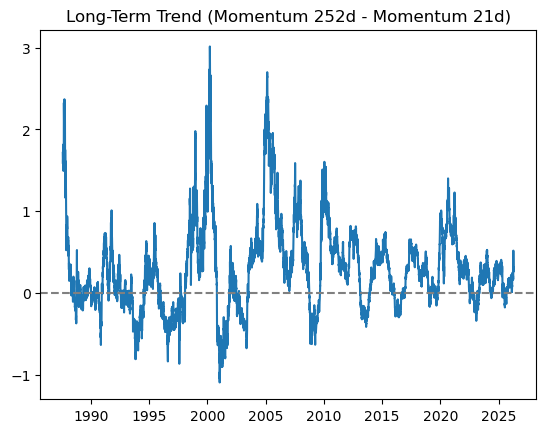

In [46]:
def calculate_momentum_feature(df):
    # momentum_21d = (Price_today - Price_21d_ago) / Price_21d_ago
    df["momentum_21d"] = (df["Close"] - df["Close"].shift(21)) / df["Close"].shift(21)
    df["momentum_21d"].tail(10)

    plt.figure()
    plt.plot(df["momentum_21d"])
    plt.axhline(0, color="gray", linestyle="--")
    plt.title("Short-Term Trend (Momentum 21d)")

    # momentum_252_21d = [(Price_today - Price_252d_ago) / Price_252d_ago] - [(Price_today - Price_21d_ago) / Price_21d_ago]
    # momentum_252_21d = pct_change(252) - pct_change(21)
    df["momentum_252_21d"] = df["Close"].pct_change(252) - df["Close"].pct_change(21)
    df["momentum_252_21d"].tail(10)
    
    plt.figure()
    plt.plot(df["momentum_252_21d"])
    plt.axhline(0, color="gray", linestyle="--")
    plt.title("Long-Term Trend (Momentum 252d - Momentum 21d)")

    return df

df = calculate_momentum_feature(df)


Measuring Volatility:

3. Volatility Ratio: what regime are we in? is volatility expanding or contracting? if > 1, volatility is increasing (recent 5d more volatile than usual 20d), market getting nervous; if Ratio < 1 → volatility is decreasing → market calming down; Ratio ≈ 1 → stable
- this matters, because strategies behave differently in high-vol vs. low-vol regimes. Momentum works in calm markets, mean-reversion works in volatile markets
4. Historical Volatility - a risk measure, measured in log returns. Why log returns? Because they're additive over time and more normally distributed than simple returns. If HV_20 = 0.30, the stock moves about 30% per year. Higher HV = riskier asset

Text(0, 0.5, 'Ratio')

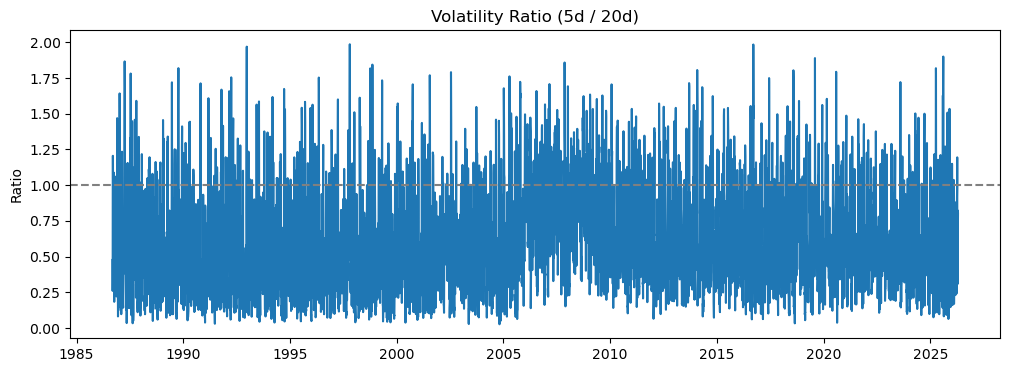

In [47]:
# Measuring Volatility: Volatility Ratio, Historical Volatility
# Vol_Ratio = std(log_returns, 5 days) / std(log_returns, 20 days)
log_returns = np.log(df["Close"]) / df["Close"].shift(1)
df["vol_ratio"] = log_returns.rolling(window=5).std() / log_returns.rolling(window=20).std()
df["vol_ratio"].tail(10)

plt.figure(figsize=(12, 4))
plt.plot(df["vol_ratio"])
plt.axhline(1, color="gray", linestyle="--")
plt.title("Volatility Ratio (5d / 20d)")
plt.ylabel("Ratio")


# log_returns = ln(Close_t / Close_{t-1})
# HV_20 = std(log_returns, 20 days) × √252



Measuring Microstructure:

5. Amihuid Illiquidity

How much does the price move per dollar of volume?


Illiquidity = mean( |daily_return| / daily_volume, 20 days )
High Amihud → small volume causes big price moves → illiquid (dangerous, hard to trade)
Low Amihud → large volume barely moves price → liquid (safe, easy to trade)
This tells the model: "can I actually execute this trade without moving the market against me?" A stock with great signals but terrible liquidity is untradeable in practice.

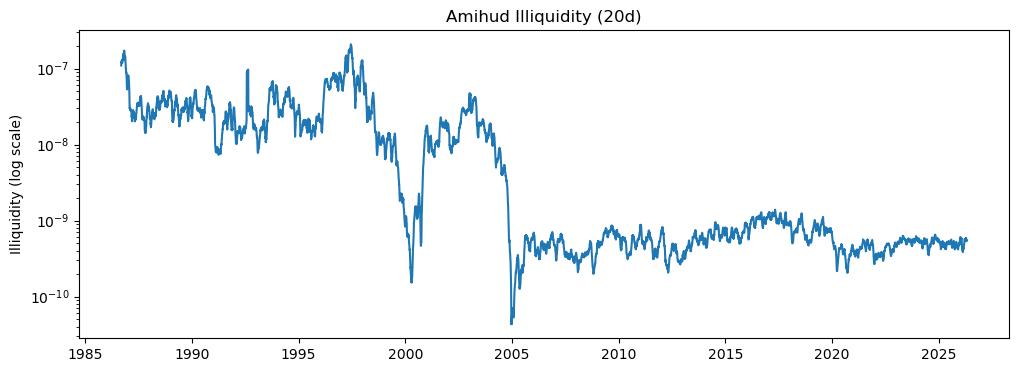

In [48]:
# Illiquidity = mean( |daily_return| / daily_volume, 20 days)

df["illiquidity"] = (log_returns.abs() / df["Volume"]).rolling(window=20).mean()
df["illiquidity"].tail(10)

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["illiquidity"])
plt.yscale("log")
plt.title("Amihud Illiquidity (20d)")
plt.ylabel("Illiquidity (log scale)")
plt.show()

Measuring Autocorrelation:

6. Return Autocorrelation (20d) - "what regime are we in?"

Does the market trend or mean-revert?

- Autocorrelation asks: "if the stock went up today, does it tend to go up again tomorrow?"
- Day 1: +1%  → Day 2: +0.8%  → Day 3: +1.2%   (positive autocorrelation = trending)
- Day 1: +1%  → Day 2: -0.9%  → Day 3: +0.7%   (negative autocorrelation = mean-reverting)
- Day 1: +1%  → Day 2: +0.3%  → Day 3: -1.5%   (near zero = random)
- It's just the correlation between today's return and yesterday's return over a rolling window of 20 days.

Example:
- autocorr = +0.5 → today's move predicts tomorrow's move in the same direction → trend is real
- autocorr = -0.5 → today's move predicts tomorrow's move in the opposite direction → price bounces back
- autocorr = 0 → today tells you nothing about tomorrow → random walk

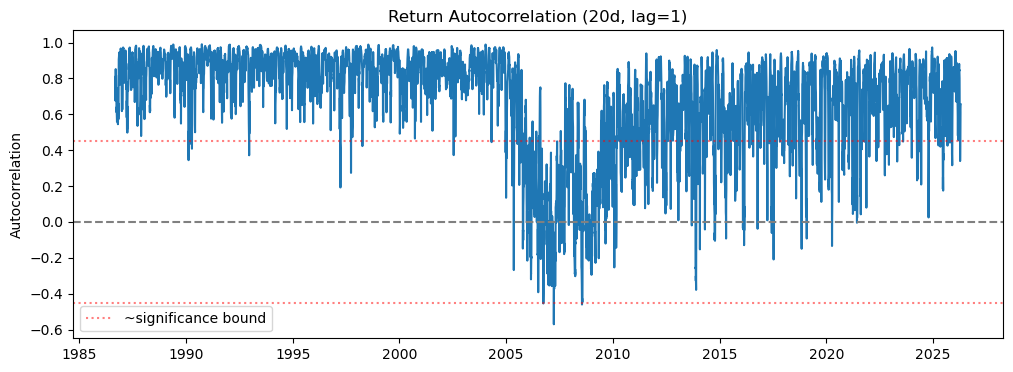

In [49]:
# Autocorr_20 = correlation(returns[t], returns[t-1]) over 20 days

df["autocorr_20"] = log_returns.rolling(window=20).apply(lambda x: x.autocorr(lag=1))
df["autocorr_20"].tail(10)    

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["autocorr_20"])
plt.axhline(0, color="gray", linestyle="--")
plt.axhline(0.45, color="red", linestyle=":", alpha=0.5, label="~significance bound")
plt.axhline(-0.45, color="red", linestyle=":", alpha=0.5)
plt.title("Return Autocorrelation (20d, lag=1)")
plt.ylabel("Autocorrelation")
plt.legend()
plt.show()

In [51]:
# Validating Quant Features: Momentum, Volatility Ratio, Illiquidity, Autocorrelation
# Do any of this features actually predict future returns?
# Drop a feature only if it has: zero individual correlation AND high correlation with another feature (redundant)

df["fwd_return"] = df["Close"].pct_change(1).shift(-1)
features = ["momentum_21d", "momentum_252_21d", "vol_ratio", "illiquidity", "autocorr_20"]

print("Correlation with forward returns:")
print(df[features].corrwith(df["fwd_return"]))

print("\nFeature correlation matrix:")
print(df[features].corr().round(2))

from statsmodels.tsa.stattools import adfuller
print("\nADF test (p < 0.05 = stationary):")
for f in features:
    p_val = adfuller(df[f].dropna())[1]
    check = '✓' if p_val < 0.05 else '✗'
    print(f"  {f}: p={p_val:.4f} {check}")

Correlation with forward returns:
Price
momentum_21d        0.001512
momentum_252_21d    0.003170
vol_ratio           0.007455
illiquidity         0.005932
autocorr_20        -0.004564
dtype: float64

Feature correlation matrix:
Price             momentum_21d  momentum_252_21d  vol_ratio  illiquidity  \
Price                                                                      
momentum_21d              1.00              0.08      -0.14        -0.07   
momentum_252_21d          0.08              1.00       0.07        -0.36   
vol_ratio                -0.14              0.07       1.00        -0.10   
illiquidity              -0.07             -0.36      -0.10         1.00   
autocorr_20               0.08             -0.13      -0.46         0.31   

Price             autocorr_20  
Price                          
momentum_21d             0.08  
momentum_252_21d        -0.13  
vol_ratio               -0.46  
illiquidity              0.31  
autocorr_20              1.00  

ADF test (p <